# Experiment 7: Text Classification using RNN

**Course:** AML ZC417 – Introduction to Deep Learning
**Module Reference:** Module 8 — Recurrent Neural Networks (RNN, LSTM, GRU)
**Duration:** 2 hours

---

## Aim
To build, train, and evaluate RNN-based models (SimpleRNN, LSTM, and Bidirectional LSTM) for binary sentiment classification of movie reviews, and to understand how text is represented numerically for use in a neural network.

## Learning Outcomes
By the end of this experiment, you will be able to:
1. Explain how raw text is converted into a numeric form (tokenization, integer encoding, padding) suitable for a neural network.
2. Explain the role of an Embedding layer in learning dense word representations.
3. Build and train RNN-based models for text classification using Keras.
4. Compare a plain RNN, an LSTM, and a Bidirectional LSTM on the same text classification task.
5. Evaluate a text classifier using accuracy, precision, recall, and a confusion matrix.
6. Use a trained model to classify new, unseen text.


## Part 0 — Setup and Dataset

We use the **IMDB Movie Reviews dataset**: 50,000 movie reviews labeled as positive (1) or negative (0) sentiment. Keras provides this dataset pre-tokenized: each review is already an integer sequence, where each integer represents a specific word's rank in the overall word-frequency table (e.g. 3 = the 3rd most frequent word in the dataset).


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

VOCAB_SIZE = 10000   # only consider the top 10,000 most frequent words
MAX_LEN = 200        # truncate/pad every review to 200 words


TensorFlow version: 2.21.0


In [24]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("Number of training reviews:", len(x_train_full))
print("Number of test reviews:", len(x_test))
print("Example review (as integers):", x_train_full[0][:20], "...")
print("Label (0=negative, 1=positive):", y_train_full[0])


Number of training reviews: 25000
Number of test reviews: 25000
Example review (as integers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...
Label (0=negative, 1=positive): 1


In [25]:
# Decode the first review back to words, to see what the raw text actually looked like
word_index = keras.datasets.imdb.get_word_index()
# The first few indices are reserved for special tokens
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print(decode_review(x_train_full[0]))


<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wha

**Note:** The word index is off by 3 because indices 0, 1, and 2 are reserved for padding, the start-of-sequence marker, and unknown/rare words respectively.


---
## Part 1 — Preparing the Data: Padding to a Fixed Length

Neural networks require inputs of a consistent shape, but reviews naturally have different lengths. We solve this with **padding**: reviews shorter than `MAX_LEN` are padded with zeros at the start, and reviews longer than `MAX_LEN` are truncated.


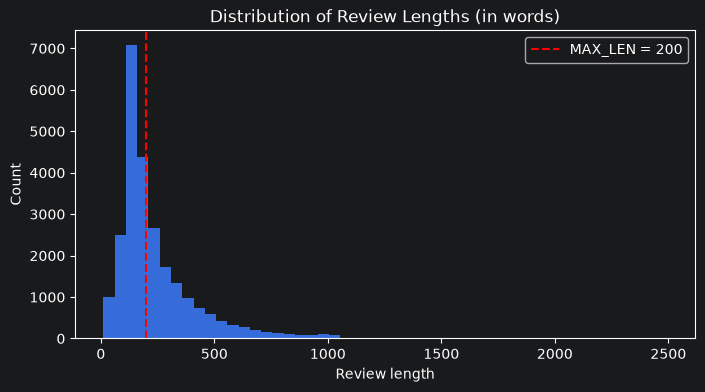

Mean length: 238.7, Median length: 178.0


In [26]:
review_lengths = [len(r) for r in x_train_full]
plt.figure(figsize=(8, 4))
plt.hist(review_lengths, bins=50)
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.title("Distribution of Review Lengths (in words)")
plt.xlabel("Review length"); plt.ylabel("Count"); plt.legend()
plt.show()

print(f"Mean length: {np.mean(review_lengths):.1f}, Median length: {np.median(review_lengths):.1f}")


In [27]:
x_train_full_padded = keras.preprocessing.sequence.pad_sequences(x_train_full, maxlen=MAX_LEN)
x_test_padded = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=MAX_LEN)

# Hold out a validation set
x_train, x_val = x_train_full_padded[:20000], x_train_full_padded[20000:]
y_train, y_val = y_train_full[:20000], y_train_full[20000:]

print("Train shape:", x_train.shape, "| Val shape:", x_val.shape, "| Test shape:", x_test_padded.shape)
print("Example padded review (first 30 values):", x_train[0][:30])


Train shape: (20000, 200) | Val shape: (5000, 200) | Test shape: (25000, 200)
Example padded review (first 30 values): [   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38]


---
## Part 2 — The Embedding Layer

Integer word IDs (e.g. 3, 17, 891) have no meaningful numeric relationship to each other — word ID 4 is not "twice as important" as word ID 2. An **Embedding layer** solves this by learning a dense, low-dimensional vector representation for each word during training, such that words used in similar contexts end up with similar vectors. This is conceptually similar to how a Dense layer's weights are learned, except here each row of the weight matrix corresponds to one word's vector.


In [28]:
EMBEDDING_DIM = 32

# Demonstration: an Embedding layer maps each integer ID to a learned vector
demo_embedding = keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)
sample_input = x_train[0:1]                 # shape (1, MAX_LEN)
sample_output = demo_embedding(sample_input)
print("Input shape (batch, timesteps):", sample_input.shape)
print("Output shape (batch, timesteps, embedding_dim):", sample_output.shape)


Input shape (batch, timesteps): (1, 200)
Output shape (batch, timesteps, embedding_dim): (1, 200, 32)


**Note:** At this point the embedding vectors are randomly initialized and meaningless — they will only become meaningful once trained as part of a full classification model in the next steps.


---
## Part 3 — Building a SimpleRNN Text Classifier

A typical RNN-based text classifier stacks: **Embedding -> RNN layer -> Dense (sigmoid) output**. The Embedding layer converts word IDs into dense vectors; the RNN layer processes the sequence of vectors and produces a single summary representation; the final Dense layer maps this to a probability of positive sentiment.


In [29]:
def build_simple_rnn():
    model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,)),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
        keras.layers.SimpleRNN(32),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

rnn_model = build_simple_rnn()
rnn_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history_rnn = rnn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=8,
    batch_size=64,
    verbose=2,
)


Epoch 1/8
313/313 - 6s - 19ms/step - accuracy: 0.7336 - loss: 0.5232 - val_accuracy: 0.8130 - val_loss: 0.4241
Epoch 2/8
313/313 - 4s - 13ms/step - accuracy: 0.8607 - loss: 0.3362 - val_accuracy: 0.8078 - val_loss: 0.4271
Epoch 3/8
313/313 - 4s - 14ms/step - accuracy: 0.9154 - loss: 0.2213 - val_accuracy: 0.8354 - val_loss: 0.4089
Epoch 4/8
313/313 - 4s - 13ms/step - accuracy: 0.9529 - loss: 0.1359 - val_accuracy: 0.8330 - val_loss: 0.4810
Epoch 5/8
313/313 - 4s - 14ms/step - accuracy: 0.9226 - loss: 0.1918 - val_accuracy: 0.8178 - val_loss: 0.5315
Epoch 6/8
313/313 - 4s - 14ms/step - accuracy: 0.9740 - loss: 0.0788 - val_accuracy: 0.7924 - val_loss: 0.6149
Epoch 7/8
313/313 - 4s - 14ms/step - accuracy: 0.9932 - loss: 0.0283 - val_accuracy: 0.8094 - val_loss: 0.6855
Epoch 8/8
313/313 - 4s - 13ms/step - accuracy: 0.9962 - loss: 0.0169 - val_accuracy: 0.8264 - val_loss: 0.7043


In [31]:
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test_padded, y_test, verbose=0)
print(f"SimpleRNN -- Test accuracy: {rnn_test_acc:.4f}, Test loss: {rnn_test_loss:.4f}")


SimpleRNN -- Test accuracy: 0.8160, Test loss: 0.7250


**What to look for:** A plain SimpleRNN often struggles on longer sequences like these 200-word reviews, since sentiment-carrying words can appear far from the end of the sequence, and (as in Experiment 6) SimpleRNN is prone to losing information from early timesteps due to the vanishing gradient problem.


---
## Part 4 — Building an LSTM Text Classifier

We now replace the SimpleRNN layer with an LSTM layer, which — as covered in Experiment 6 — uses gating mechanisms to retain relevant information over much longer sequences.


In [32]:
def build_lstm():
    model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,)),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
        keras.layers.LSTM(32),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

lstm_model = build_lstm()
history_lstm = lstm_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=8,
    batch_size=64,
    verbose=2,
)


Epoch 1/8
313/313 - 11s - 37ms/step - accuracy: 0.7819 - loss: 0.4449 - val_accuracy: 0.8682 - val_loss: 0.3099
Epoch 2/8
313/313 - 10s - 33ms/step - accuracy: 0.9021 - loss: 0.2503 - val_accuracy: 0.8654 - val_loss: 0.3170
Epoch 3/8
313/313 - 10s - 33ms/step - accuracy: 0.9219 - loss: 0.2100 - val_accuracy: 0.8466 - val_loss: 0.4073
Epoch 4/8
313/313 - 10s - 33ms/step - accuracy: 0.9318 - loss: 0.1838 - val_accuracy: 0.8694 - val_loss: 0.3349
Epoch 5/8
313/313 - 11s - 36ms/step - accuracy: 0.9403 - loss: 0.1619 - val_accuracy: 0.8704 - val_loss: 0.3660
Epoch 6/8
313/313 - 16s - 50ms/step - accuracy: 0.9586 - loss: 0.1197 - val_accuracy: 0.8678 - val_loss: 0.3996
Epoch 7/8
313/313 - 17s - 55ms/step - accuracy: 0.9398 - loss: 0.1599 - val_accuracy: 0.8460 - val_loss: 0.4034
Epoch 8/8
313/313 - 18s - 57ms/step - accuracy: 0.9596 - loss: 0.1091 - val_accuracy: 0.8478 - val_loss: 0.4096


In [33]:
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(x_test_padded, y_test, verbose=0)
print(f"LSTM -- Test accuracy: {lstm_test_acc:.4f}, Test loss: {lstm_test_loss:.4f}")


LSTM -- Test accuracy: 0.8450, Test loss: 0.4223


---
## Part 5 — Building a Bidirectional LSTM Text Classifier

A standard (unidirectional) LSTM only reads a sequence left-to-right, so at any point it only "knows" what came before, not what comes after. A **Bidirectional LSTM** runs two LSTM layers simultaneously — one reading the sequence forward, one reading it backward — and concatenates their outputs. For text classification, this often helps because the sentiment-relevant meaning of a word can depend on words that appear later in the sentence (e.g. negations like "not... good").


In [34]:
def build_bilstm():
    model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,)),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
        keras.layers.Bidirectional(keras.layers.LSTM(32)),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

bilstm_model = build_bilstm()
bilstm_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,705 (1.28 MB)

 Trainable params: 336,705 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history_bilstm = bilstm_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=8,
    batch_size=64,
    verbose=2,
)


Epoch 1/8
313/313 - 22s - 70ms/step - accuracy: 0.7715 - loss: 0.4687 - val_accuracy: 0.8536 - val_loss: 0.3475
Epoch 2/8
313/313 - 17s - 56ms/step - accuracy: 0.8955 - loss: 0.2643 - val_accuracy: 0.8774 - val_loss: 0.3158
Epoch 3/8
313/313 - 17s - 56ms/step - accuracy: 0.9241 - loss: 0.2036 - val_accuracy: 0.8760 - val_loss: 0.3474
Epoch 4/8
313/313 - 18s - 57ms/step - accuracy: 0.9362 - loss: 0.1746 - val_accuracy: 0.8744 - val_loss: 0.3436
Epoch 5/8
313/313 - 18s - 58ms/step - accuracy: 0.9409 - loss: 0.1597 - val_accuracy: 0.8626 - val_loss: 0.3668
Epoch 6/8
313/313 - 18s - 57ms/step - accuracy: 0.9488 - loss: 0.1421 - val_accuracy: 0.8496 - val_loss: 0.4075
Epoch 7/8
313/313 - 18s - 56ms/step - accuracy: 0.9538 - loss: 0.1278 - val_accuracy: 0.8250 - val_loss: 0.4579
Epoch 8/8
313/313 - 18s - 57ms/step - accuracy: 0.9531 - loss: 0.1302 - val_accuracy: 0.8434 - val_loss: 0.4479


In [36]:
bilstm_test_loss, bilstm_test_acc = bilstm_model.evaluate(x_test_padded, y_test, verbose=0)
print(f"Bidirectional LSTM -- Test accuracy: {bilstm_test_acc:.4f}, Test loss: {bilstm_test_loss:.4f}")


Bidirectional LSTM -- Test accuracy: 0.8412, Test loss: 0.4574


---
## Part 6 — Comparing All Models


In [37]:
print(f"{'Model':<22}{'Test Accuracy':>15}{'Test Loss':>12}")
print("-" * 49)
print(f"{'SimpleRNN':<22}{rnn_test_acc:>15.4f}{rnn_test_loss:>12.4f}")
print(f"{'LSTM':<22}{lstm_test_acc:>15.4f}{lstm_test_loss:>12.4f}")
print(f"{'Bidirectional LSTM':<22}{bilstm_test_acc:>15.4f}{bilstm_test_loss:>12.4f}")


Model                   Test Accuracy   Test Loss
-------------------------------------------------
SimpleRNN                      0.8160      0.7250
LSTM                           0.8450      0.4223
Bidirectional LSTM             0.8412      0.4574


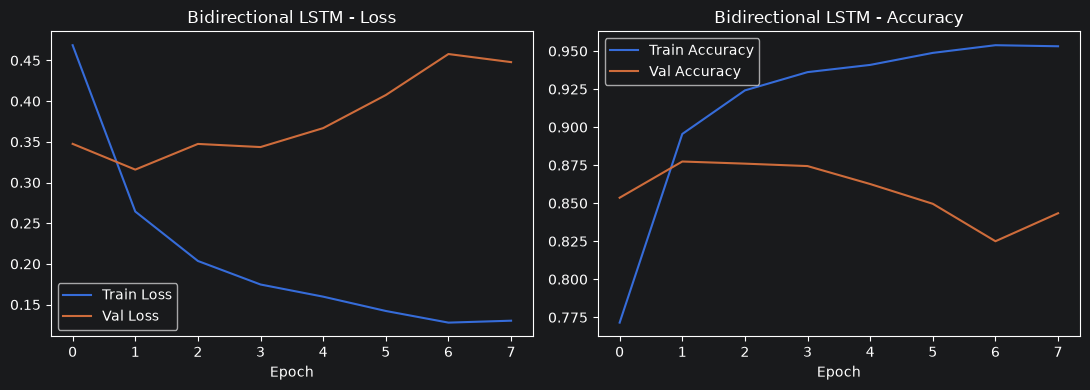

In [38]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} - Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[1].set_title(f"{title} - Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_bilstm, "Bidirectional LSTM")


---
## Part 7 — Detailed Evaluation of the Best Model

We use the Bidirectional LSTM (typically the strongest of the three) for a closer look: a confusion matrix and a full classification report (precision, recall, F1-score).


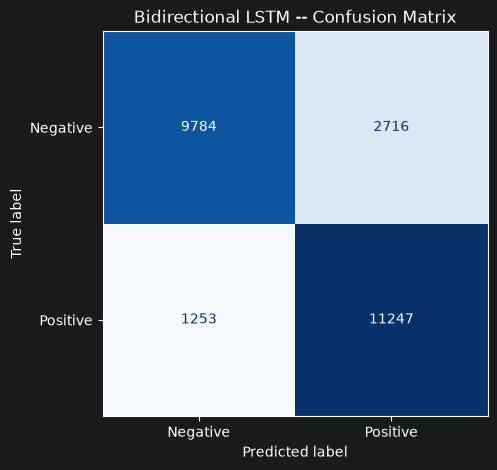

              precision    recall  f1-score   support

    Negative       0.89      0.78      0.83     12500
    Positive       0.81      0.90      0.85     12500

    accuracy                           0.84     25000
   macro avg       0.85      0.84      0.84     25000
weighted avg       0.85      0.84      0.84     25000



In [39]:
y_pred_probs = bilstm_model.predict(x_test_padded, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Bidirectional LSTM -- Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))


---
## Part 8 — Classifying New, Unseen Text

Finally, we use the trained model to classify a few new sentences that were not part of the dataset, to see how it generalizes to genuinely new text.


In [40]:
def encode_text(text, word_index, vocab_size=VOCAB_SIZE, max_len=MAX_LEN):
    words = text.lower().split()
    encoded = [1]   # <START> token
    for word in words:
        idx = word_index.get(word, 2) + 3   # 2 = <UNK>, offset by 3 as in the dataset
        encoded.append(idx if idx < vocab_size else 2)
    return keras.preprocessing.sequence.pad_sequences([encoded], maxlen=max_len)

new_reviews = [
    "this movie was absolutely fantastic and the acting was superb",
    "what a terrible waste of time the plot made no sense at all",
    "it was okay, not great but not bad either, a fairly average film",
]

for review in new_reviews:
    encoded = encode_text(review, word_index)
    prob = bilstm_model.predict(encoded, verbose=0)[0, 0]
    sentiment = "Positive" if prob > 0.5 else "Negative"
    print(f"Review: \"{review}\"")
    print(f"  -> Predicted: {sentiment} (confidence: {prob:.3f})\n")


Review: "this movie was absolutely fantastic and the acting was superb"
  -> Predicted: Positive (confidence: 0.956)

Review: "what a terrible waste of time the plot made no sense at all"
  -> Predicted: Negative (confidence: 0.015)

Review: "it was okay, not great but not bad either, a fairly average film"
  -> Predicted: Negative (confidence: 0.374)



**What to look for:** Clearly positive and clearly negative reviews should be classified correctly with high confidence. The neutral/mixed review is a genuinely harder case, and the model's confidence for it is often noticeably closer to 0.5 -- reflecting real uncertainty rather than a wrong answer.


---
## Part 9 — In-Lab Exercise (to be completed and shown to the instructor)

1. Change `MAX_LEN` to **50** and to **400**, retrain the LSTM model (Part 4) for each, and report test accuracy for both. What happens to accuracy and training time as `MAX_LEN` increases, and why?
2. Change `VOCAB_SIZE` to **2000** (a much smaller vocabulary) and retrain the LSTM model. Does accuracy drop significantly? What does this suggest about how much of the vocabulary is actually needed for sentiment classification?
3. Add a **second LSTM layer** to the Bidirectional LSTM model (hint: the first LSTM layer needs `return_sequences=True` so its full output sequence can feed into the second layer). Does test accuracy improve?
4. Write **three of your own review sentences** (not copied from anywhere in this notebook) — one clearly positive, one clearly negative, and one ambiguous/mixed — and classify them using your best-performing model. Do the predictions match your expectations?
5. In 3–4 sentences, summarize which model performed best overall in your experiments, and explain in your own words why a Bidirectional LSTM might outperform a standard LSTM for sentiment classification specifically.


In [41]:
# TODO 1: MAX_LEN = 50 and MAX_LEN = 400 experiments
# your code here


_TODO 1 (continued): Your explanation here._

In [42]:
# TODO 2: VOCAB_SIZE = 2000 experiment
# your code here


_TODO 2 (continued): Your explanation here._

In [43]:
# TODO 3: Stacked Bidirectional LSTM (two layers)
# your code here


In [44]:
# TODO 4: Classify your own three review sentences
# your code here


_TODO 5: Your summary here._

---
## Post-Lab Viva Questions

1. Why can't raw word-ID integers be fed directly into a Dense or RNN layer in a meaningful way without an Embedding layer?
2. What does the Embedding layer actually learn during training, and how is this different from one-hot encoding each word?
3. Why is padding necessary, and what could go wrong if reviews of different lengths were fed into the network without padding?
4. Why might a Bidirectional LSTM outperform a standard (unidirectional) LSTM specifically on sentiment classification?
5. In the classification report, what is the difference between precision and recall, and why might one matter more than the other in a specific application (e.g. spam detection vs. medical screening)?
6. If a review contains a negation like "not good," why might a plain RNN struggle to correctly classify it, while an LSTM handles it better?

---
*End of Experiment 7*
